In [1]:
from hbnm.io import Data

# Define data object
input_dir = '/home/frank/HBNM/data/'
output_dir = '/home/frank/HBNM/outputs/'
data = Data(input_dir, output_dir)

In [ ]:
dem_data = data.load('demirtas_neuron_2019.hdf5')
dem_data.keys()

<KeysViewHDF5 ['alphabeta_removed_meg_pc1', 'apprx_posterior_heterogeneous', 'apprx_posterior_homogeneous', 'fc', 'fc_heterogeneous', 'fc_homogeneous', 'heterogeneity_maps', 'raw_meg_pc1', 'sc', 't1wt2w']>

In [11]:
dem_data['heterogeneity_maps'][:].shape

(360, 10)

In [3]:
import numpy as np
import pandas as pd

# Load myelin data (should be shape (1, 180))
myelin_raw = np.load('/home/frank/HBNM/data/heterogeneity_vectors/raw/myelin_raw.npy')

# Transform myelin_raw to shape (180,)
myelin_raw_flat = myelin_raw.flatten()

# Load parcellation dataframe (should have 180 regions)
parcellation_df_L = pd.read_csv('/home/frank/HBNM/data/parcellation_df_L.csv')

# Match myelin values to parcellation dataframe by region index
# Assuming both are in the same order; if not, further matching by region label is needed
parcellation_df_L['myelin'] = myelin_raw_flat


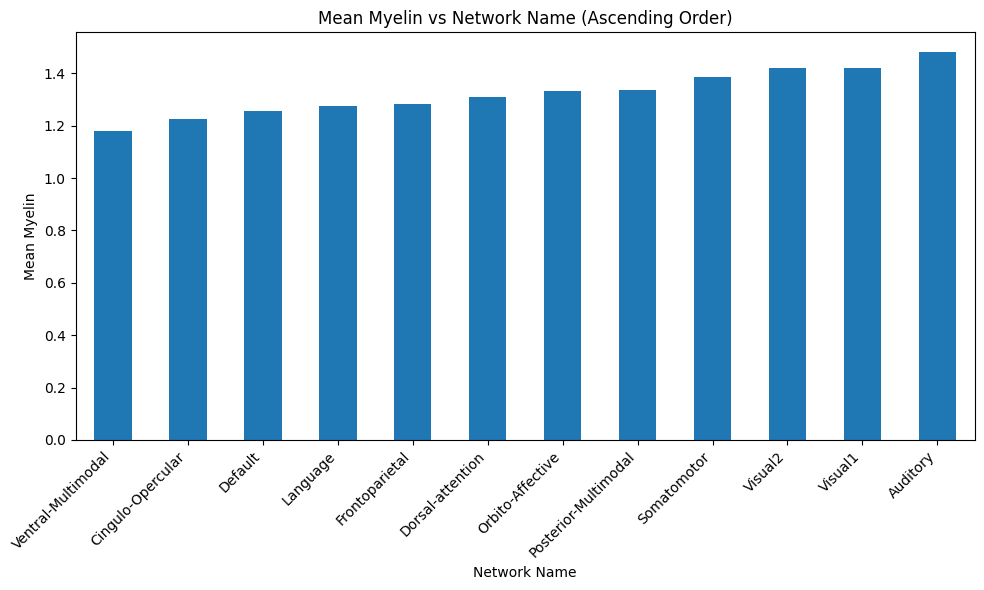

In [7]:
import matplotlib.pyplot as plt

# Compute mean myelin for each unique NetworkName and sort in ascending order
network_myelin_means = parcellation_df_L.groupby('NetworkName')['myelin'].mean().sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))
network_myelin_means.plot(kind='bar')
plt.ylabel('Mean Myelin')
plt.xlabel('Network Name')
plt.title('Mean Myelin vs Network Name (Ascending Order)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()